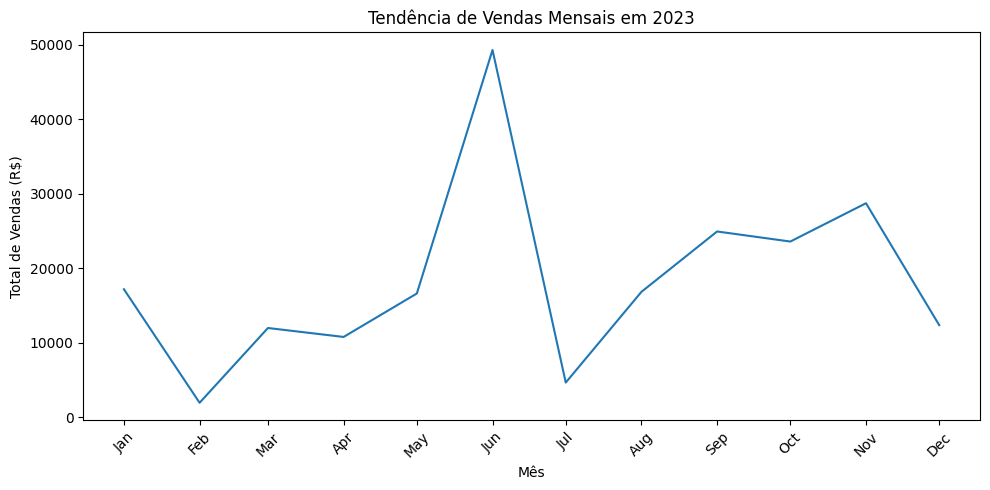

In [4]:
# ANÁLISE EXPLORATÓRIA DE DADOS DE VENDAS
# GRÁFICO DE TENDÊNCIA MENSAL

# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt

# Carrega o dataset limpo
df = pd.read_csv("data_clean.csv")

# Converte a coluna Data para o formato datetime
df["Data"] = pd.to_datetime(df["Data"])

# CRIA A COLUNA TOTAL_VENDA 
df["Total_Venda"] = (df["Quantidade"] * df["Preço"]).round(2)

# CRIA COLUNA DE ANO E MÊS PARA AGRUPAMENTO
df["Ano_Mes"] = df["Data"].dt.to_period("M")

# AGRUPA AS VENDAS POR MÊS
vendas_mensais = (
    df.groupby("Ano_Mes")["Total_Venda"]
    .sum()
    .reset_index()
)

# CRIA UMA SEQUÊNCIA COM TODOS OS MESES DE 2023
todos_meses = pd.period_range(
    start="2023-01",
    end="2023-12",
    freq="M"
)

# CONVERTE PARA DATAFRAME
df_meses = pd.DataFrame({"Ano_Mes": todos_meses})

# JUNTA TODOS OS MESES COM AS VENDAS EXISTENTES
vendas_mensais = df_meses.merge(
    vendas_mensais,
    on="Ano_Mes",
    how="left"
)

# SUBSTITUI MESES SEM VENDA POR ZERO
vendas_mensais["Total_Venda"].fillna(0, inplace=True)

# Converte Ano_Mes para datetime 
vendas_mensais["Ano_Mes"] = vendas_mensais["Ano_Mes"].dt.to_timestamp()

# CRIA O GRÁFICO DE LINHA
plt.figure(figsize=(10, 5))
plt.plot(vendas_mensais["Ano_Mes"], vendas_mensais["Total_Venda"])
plt.title("Tendência de Vendas Mensais em 2023")
plt.xlabel("Mês")
plt.ylabel("Total de Vendas (R$)")
plt.xticks(rotation=45)

# DEFINE OS RÓTULOS DO EIXO X PARA TODOS OS MESES
plt.xticks(
    vendas_mensais["Ano_Mes"],
    vendas_mensais["Ano_Mes"].dt.strftime("%b"),
    rotation=45
)





plt.tight_layout()

# Exibe o gráfico
plt.show()

Insight 1 — Variação mensal de vendas
É possível observar que as vendas não se mantêm constantes ao longo do ano, apresentando picos em determinados meses, 
o que pode indicar sazonalidade ou maior demanda em períodos específicos. 

Insight 2- Alguns meses concentram um volume maior de vendas, enquanto outros apresentam queda, 
o que pode auxiliar a empresa em decisões como promoções, planejamento de estoque ou campanhas de marketing